# Notebook 1: Interpretable Feature Families

This notebook demonstrates each feature family implemented in `tsshap/features/`.  
We use the classic CO2 dataset (monthly Mauna Loa observations) as a concrete example

Feature families covered:
1. **STLFeatures** — trend, seasonal, residual via Seasonal-Trend Decomposition (LOESS)
2. **LagFeatures** / **SeasonalLagFeatures** — past values
3. **RollingWindowFeatures** / **ExpandingWindowFeatures** — window statistics
4. **TrendFeatures** — polynomial time index
5. **DateFeatures** — calendar encodings

Black-box forecasters live in `tsshap.forecasters` (see README); notebooks **02–03** exercise them alongside TsSHAP.

Series length: 526, range: 1958-03-31 to 2001-12-31


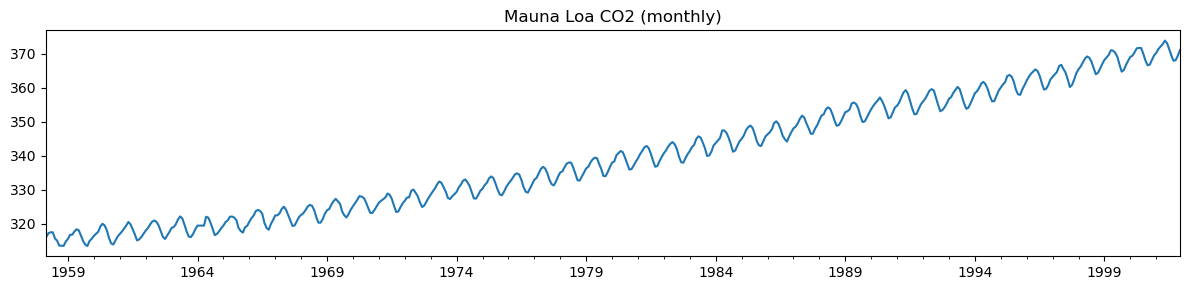

In [ ]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
from statsmodels.datasets import co2

# Load and resample CO2 data to monthly
data = co2.load().data.resample('ME').mean().ffill()
y = data['co2'].dropna()
print(f'Series length: {len(y)}, range: {y.index[0].date()} to {y.index[-1].date()}')
y.plot(title='Mauna Loa CO2 (monthly)', figsize=(12, 3))
plt.tight_layout()
plt.show()

## 1. STL Features
Uses an expanding window so each decomposition only sees data up to time t (no look-ahead).

             stl_trend  stl_seasonal  stl_residual  stl_trend_strength  \
2001-08-31  371.088213     -1.626889     -0.036325            0.999737   
2001-09-30  371.180938     -3.267737     -0.033201            0.999737   
2001-10-31  371.287535     -3.231217     -0.006318            0.999737   
2001-11-30  371.362198     -1.931439     -0.055759            0.999737   
2001-12-31  371.507373     -0.541980      0.054607            0.999737   

            stl_seasonal_strength  
2001-08-31               0.981624  
2001-09-30               0.981624  
2001-10-31               0.981624  
2001-11-30               0.981624  
2001-12-31               0.981624  


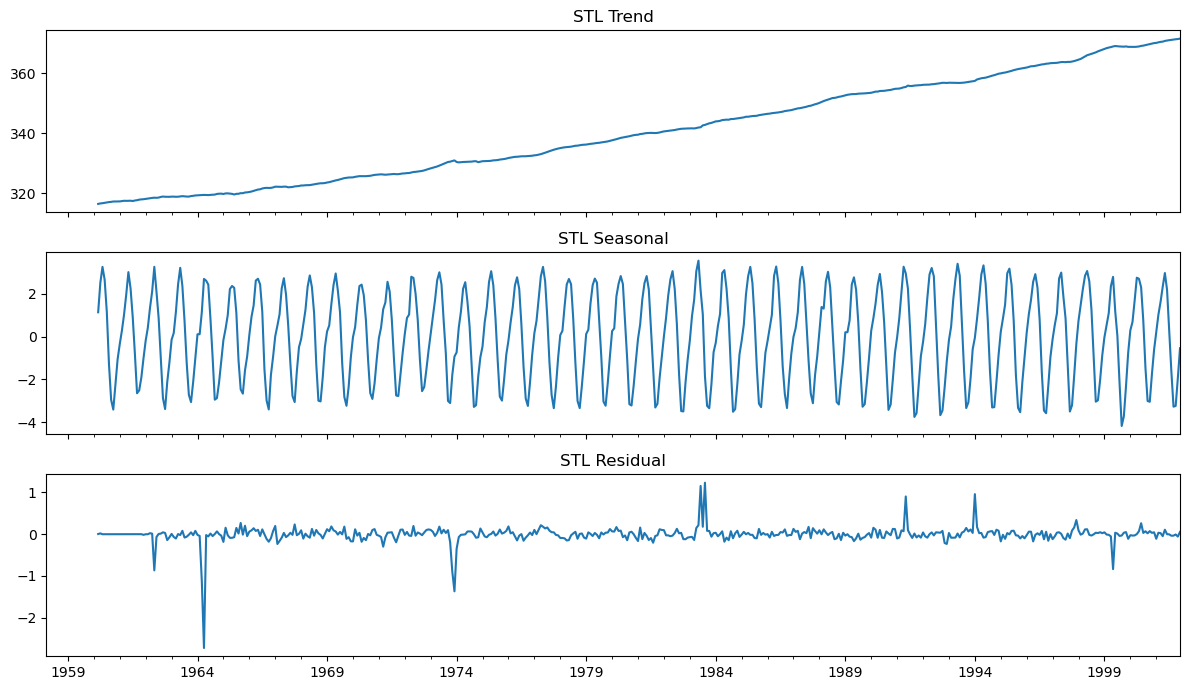

Trend strength:    1.000
Seasonal strength: 0.982


In [14]:
from tsshap.features import STLFeatures

stl = STLFeatures(period=12, robust=True)
stl_df = stl.fit_transform(y)
print(stl_df.tail())

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
stl_df['stl_trend'].plot(ax=axes[0], title='STL Trend')
stl_df['stl_seasonal'].plot(ax=axes[1], title='STL Seasonal')
stl_df['stl_residual'].plot(ax=axes[2], title='STL Residual')
plt.tight_layout()
plt.show()

print(f"Trend strength:    {stl._trend_strength:.3f}")
print(f"Seasonal strength: {stl._seasonal_strength:.3f}")

## 2. Lag Features

In [9]:
from tsshap.features import LagFeatures, SeasonalLagFeatures

lag_df = LagFeatures(lags=3).fit_transform(y)
seasonal_lag_df = SeasonalLagFeatures(lags=2, period=12).fit_transform(y)

print('Lag features (last 5 rows):')
print(lag_df.tail())
print('\nSeasonal lag features (last 5 rows):')
print(seasonal_lag_df.tail())

Lag features (last 5 rows):
             y(t-1)   y(t-2)   y(t-3)
2001-08-31  371.300  373.060  373.800
2001-09-30  369.425  371.300  373.060
2001-10-31  367.880  369.425  371.300
2001-11-30  368.050  367.880  369.425
2001-12-31  369.375  368.050  367.880

Seasonal lag features (last 5 rows):
            y(t-1*12)  y(t-2*12)
2001-08-31    367.950    366.700
2001-09-30    366.540    364.675
2001-10-31    366.725    365.140
2001-11-30    368.125    366.650
2001-12-31    369.440    367.900


## 3. Rolling and Expanding Window Features

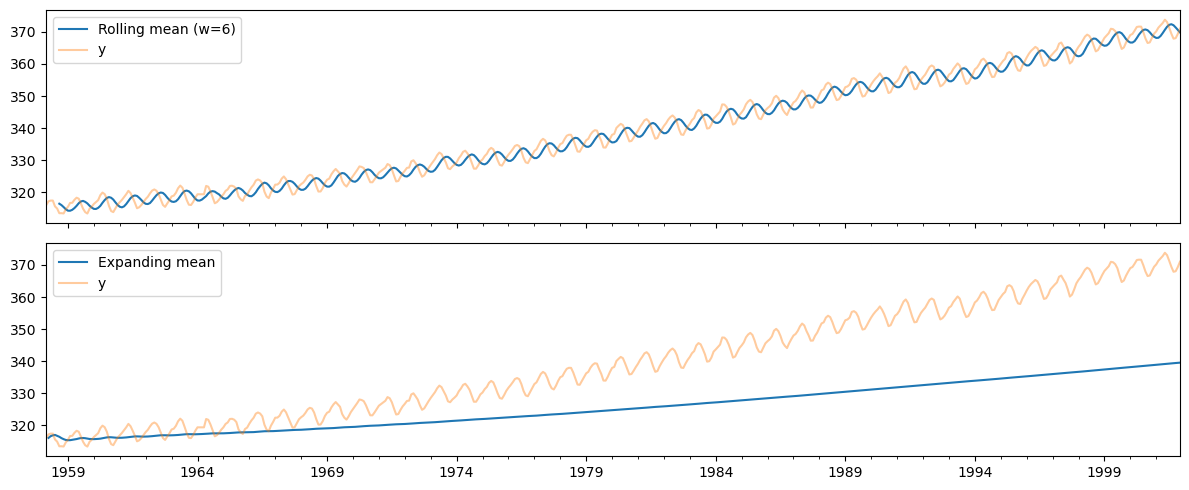

In [10]:
from tsshap.features import RollingWindowFeatures, ExpandingWindowFeatures

roll_df = RollingWindowFeatures(window=6).fit_transform(y)
exp_df  = ExpandingWindowFeatures(stats=('mean', 'std')).fit_transform(y)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
roll_df['y-mean(t-1,t-6)'].plot(ax=axes[0], label='Rolling mean (w=6)')
y.plot(ax=axes[0], alpha=0.4, label='y')
axes[0].legend()
exp_df['y-mean(0,t-1)'].plot(ax=axes[1], label='Expanding mean')
y.plot(ax=axes[1], alpha=0.4, label='y')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Trend and Date Features

In [11]:
from tsshap.features import TrendFeatures, DateFeatures

trend_df = TrendFeatures(degree=2).fit_transform(y)
date_df  = DateFeatures(features=['month', 'quarter', 'season', 'is_leap_year']).fit_transform(y)

print('Trend features (first 5 rows):')
print(trend_df.head())
print('\nDate features (first 5 rows):')
print(date_df.head())

Trend features (first 5 rows):
             t1    t2
1958-03-31  0.0   0.0
1958-04-30  1.0   1.0
1958-05-31  2.0   4.0
1958-06-30  3.0   9.0
1958-07-31  4.0  16.0

Date features (first 5 rows):
            month  quarter  season  is_leap_year
1958-03-31    3.0      1.0     2.0           0.0
1958-04-30    4.0      2.0     2.0           0.0
1958-05-31    5.0      2.0     2.0           0.0
1958-06-30    6.0      2.0     3.0           0.0
1958-07-31    7.0      3.0     3.0           0.0


## 5. Combined feature matrix
The `TsSHAPExplainer` concatenates all extractors into a single design matrix.

In [12]:
import pandas as pd

combined = pd.concat([
    stl_df,
    lag_df,
    seasonal_lag_df,
    roll_df,
    exp_df,
    trend_df,
    date_df,
], axis=1)

print(f'Combined feature matrix: {combined.shape[0]} rows × {combined.shape[1]} columns')
print(f'NaN fraction: {combined.isna().mean().mean():.2%}')
combined.tail()

Combined feature matrix: 526 rows × 22 columns
NaN fraction: 1.63%


,stl_trend,stl_seasonal,stl_residual,stl_trend_strength,stl_seasonal_strength,y(t-1),y(t-2),y(t-3),y(t-1*12),y(t-2*12),...,"y-min(t-1,t-6)","y-std(t-1,t-6)","y-mean(0,t-1)","y-std(0,t-1)",t1,t2,month,quarter,season,is_leap_year
2001-08-31,371.088213,-1.626889,-0.036325,0.999737,0.981624,371.300,373.060,373.800,367.950,366.700,...,371.300,1.001637,339.330118,16.956357,521.0,271441.0,8.0,3.0,3.0,0.0
2001-09-30,371.180938,-3.267737,-0.033201,0.999737,0.981624,369.425,371.300,373.060,366.540,364.675,...,369.425,1.553000,339.387771,16.991211,522.0,272484.0,9.0,3.0,4.0,0.0
2001-10-31,371.287535,-3.231217,-0.006318,0.999737,0.981624,367.880,369.425,371.300,366.725,365.140,...,367.880,2.310973,339.442250,17.020587,523.0,273529.0,10.0,4.0,4.0,0.0
2001-11-30,371.362198,-1.931439,-0.055759,0.999737,0.981624,368.050,367.880,369.425,368.125,366.650,...,367.880,2.532269,339.496845,17.050171,524.0,274576.0,11.0,4.0,4.0,0.0
2001-12-31,371.507373,-0.541980,0.054607,0.999737,0.981624,369.375,368.050,367.880,369.440,367.900,...,367.880,1.996684,339.553756,17.083733,525.0,275625.0,12.0,4.0,1.0,0.0
